In [36]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score

In [6]:
breast_cancer_data = load_breast_cancer()
breast_cancer_data_df = pd.DataFrame(breast_cancer_data.data,columns = breast_cancer_data.feature_names)
breast_cancer_data_df["Target"] = breast_cancer_data.target
breast_cancer_data_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [7]:
breast_cancer_data_df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64

In [8]:
breast_cancer_data_df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [9]:
X = breast_cancer_data_df.drop(columns = "Target",axis = 1)

In [10]:
y = breast_cancer_data_df["Target"]

In [2]:
zero_one_colourmap = ListedColormap(('red', 'green'))

In [3]:
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                    stop = X_set[:, 0].max() + 1, 
                                     step = 0.01),
                           np.arange(start = X_set[:, 1].min() - 1, 
                                     stop = X_set[:, 1].max() + 1, 
                                     step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                                 X2.ravel()]).T).reshape(X1.shape),
                   alpha = 0.75, 
                   cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c = (zero_one_colourmap)(i), label = j)
        plt.title('SVM Decision Boundary')
        plt.xlabel('X1')
        plt.ylabel('X2')
        plt.legend()
    return plt.show()

In [4]:
def plot_3d_plot(X, y):
  r = np.exp(-(X ** 2).sum(1))
  ax = plt.subplot(projection='3d')
  ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap=zero_one_colourmap)
  ax.set_xlabel('X1')
  ax.set_ylabel('X2')
  ax.set_zlabel('y')
  return ax

In [48]:
#Use first two columns as classes:
breast_cancer_data_df = breast_cancer_data_df.rename(columns={'mean radius': 'X1','mean texture': 'X2'})

X = breast_cancer_data_df[['X1', 'X2']].values
y = breast_cancer_data_df['Target'].values

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.25,random_state = 0)

## Linear Classifier

In [50]:
linear_classifier = SVC(kernel='linear')
linear_classifier.fit(X_train,y_train)
y_pred_test = linear_classifier.predict(X_test)

In [51]:
accuracy_score(y_test,y_pred_test)

0.9020979020979021

In [52]:
confusion_matrix(y_test,y_pred_test)

array([[46,  7],
       [ 7, 83]])

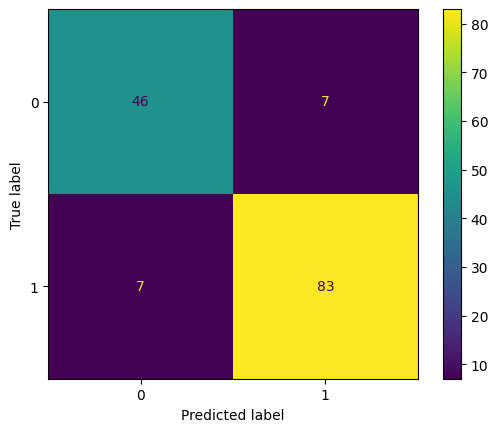

In [53]:
ConfusionMatrixDisplay.from_estimator(linear_classifier, X_test, y_test)

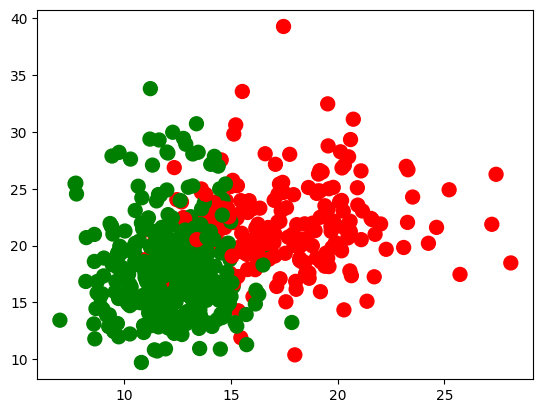

In [55]:
plt.scatter(X[:,0],X[:,1], c=y, s=100, cmap = zero_one_colourmap)
plt.show()

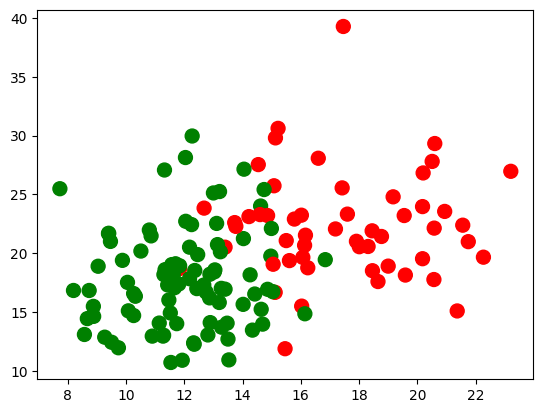

In [54]:
plt.scatter(X_test[:,0],X_test[:,1], c=y_test, s=100, cmap = zero_one_colourmap)
plt.show()

C:\Users\PAVITHRA\AppData\Local\Temp\ipykernel_8248\2791774698.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


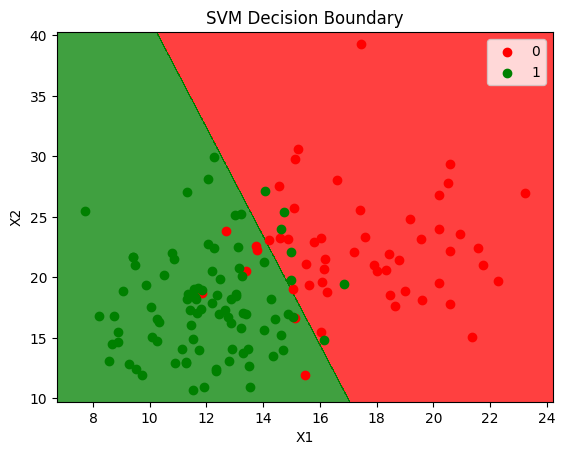

In [56]:
plot_decision_boundary(X_test, y_test, linear_classifier)

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

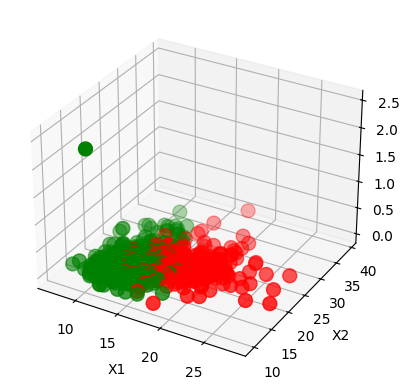

In [57]:
plot_3d_plot(X, y)

## Non Linear SVM Classifier

### rbf Classifier

In [58]:
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train,y_train)
y_pred_test = rbf_classifier.predict(X_test)

In [59]:
accuracy_score(y_test,y_pred_test)

0.8951048951048951

In [60]:
confusion_matrix(y_test,y_pred_test)

array([[44,  9],
       [ 6, 84]])

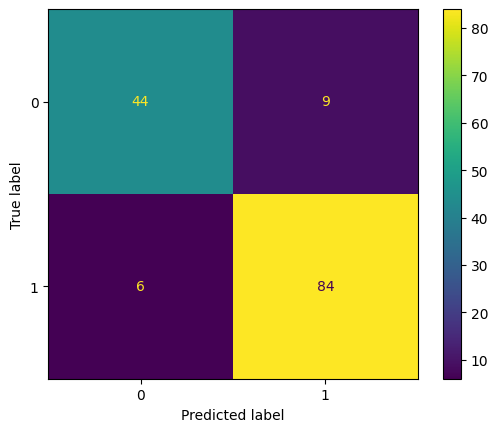

In [61]:
ConfusionMatrixDisplay.from_estimator(rbf_classifier, X_test, y_test)

C:\Users\PAVITHRA\AppData\Local\Temp\ipykernel_8248\2791774698.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


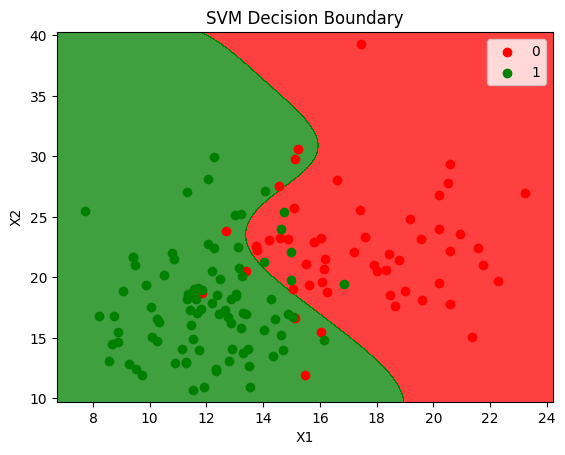

In [62]:
plot_decision_boundary(X_test, y_test, rbf_classifier)

### polynomial Classifier

In [75]:
poly_classifier = SVC(kernel='poly',C=10,gamma= 0.1)
poly_classifier.fit(X_train,y_train)
y_pred_test = poly_classifier.predict(X_test)

In [76]:
accuracy_score(y_test,y_pred_test)

0.9090909090909091

In [77]:
confusion_matrix(y_test,y_pred_test)

array([[47,  6],
       [ 7, 83]])

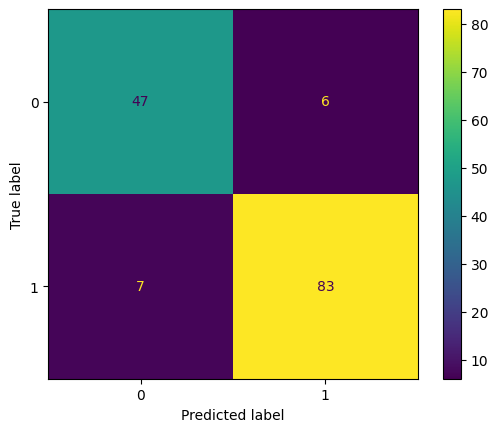

In [78]:
ConfusionMatrixDisplay.from_estimator(poly_classifier, X_test, y_test)

C:\Users\PAVITHRA\AppData\Local\Temp\ipykernel_8248\2791774698.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


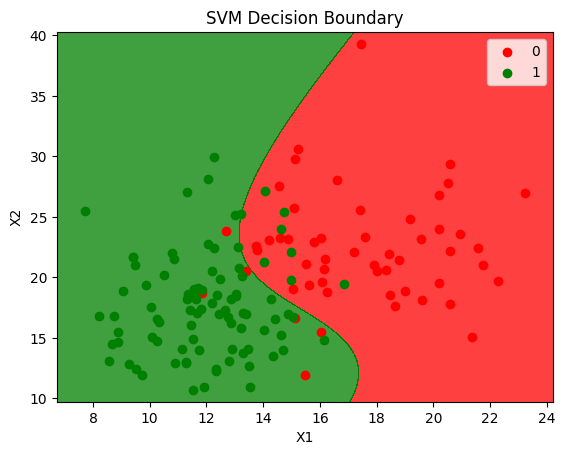

In [79]:
plot_decision_boundary(X_test, y_test, poly_classifier)